In [45]:
# Data manipulation
import pandas as pd
import numpy as np
import pickle

# Visualisation
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

In [46]:
df = pd.read_csv(r"C:\Users\BLESSETH\Downloads\British\customer_booking.csv", encoding = "latin1")

# Preview data
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [47]:
# Shape of dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 14)


In [48]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [49]:
# Summary statistics
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [50]:
print(df['booking_complete'].value_counts())
print("\nProportion:")
print(df['booking_complete'].value_counts(normalize=True))

booking_complete
0    42522
1     7478
Name: count, dtype: int64

Proportion:
booking_complete
0    0.85044
1    0.14956
Name: proportion, dtype: float64


In [51]:
def time_bucket(hour):
    if hour < 6:
        return "EarlyMorning"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df['flight_time_category'] = df['flight_hour'].apply(time_bucket)

In [52]:
df['is_weekend'] = df['flight_day'].isin(['Sat','Sun']).astype(int)

In [53]:
df['total_add_ons'] = (
    df['wants_extra_baggage'] +
    df['wants_preferred_seat'] +
    df['wants_in_flight_meals']
)

In [54]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,flight_time_category,is_weekend,total_add_ons
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0,Morning,1,1
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0,EarlyMorning,1,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0,Afternoon,0,2
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0,EarlyMorning,1,1
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0,Afternoon,0,2


In [55]:
df = pd.get_dummies(df, drop_first=True)

In [56]:
X = df.drop('booking_complete', axis=1)
y = df['booking_complete']

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [58]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [59]:
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.852


In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      8520
           1       0.00      0.00      0.00      1480

    accuracy                           0.85     10000
   macro avg       0.43      0.50      0.46     10000
weighted avg       0.73      0.85      0.78     10000



C:\Users\BLESSETH\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\BLESSETH\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\BLESSETH\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [61]:
print("ROC-AUC:", roc_auc_score(y_test, y_probs))

ROC-AUC: 0.770013917967263


In [62]:
cv_scores = cross_val_score(model, X, y, cv=5)
print("Mean CV Score:", cv_scores.mean())

Mean CV Score: 0.8504400000000001


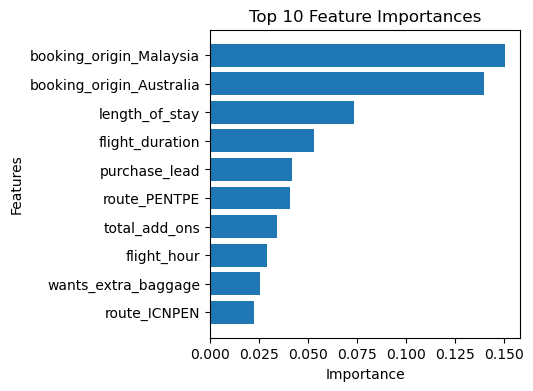

In [63]:
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(4,4))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [64]:
import pickle

# Save the trained model
pickle.dump(model, open("booking_model.pkl", "wb"))

# Save the feature column names
pickle.dump(X.columns, open("model_columns.pkl", "wb"))

print("Model and columns saved successfully")

Model and columns saved successfully


In [65]:
import pickle

model = pickle.load(open("booking_model.pkl","rb"))
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [66]:
import pickle

with open("booking_model.pkl", "rb") as file:
    model = pickle.load(file)